# 3.0 — Théorie de l'information : entropie, KL, cross-entropy

**Navigation** : [<< 2.3-Régression linéaire et logistique](../02-ML-Cours/2.3-Regression-lineaire-logistique.ipynb) · [2.8-Théorie-PAC](../02-ML-Cours/2.8-Theorie-PAC.ipynb) · [2.9-Grokking](../02-ML-Cours/2.9-Grokking-Generalisation.ipynb) · [Feuille de route de la série](README.md)

Le notebook [2.3](../02-ML-Cours/2.3-Regression-lineaire-logistique.ipynb) vous a montré que la régression logistique est ajustée par le **maximum de vraisemblance**. Ce notebook ouvre la boîte de ce qu'on optimise vraiment : la **cross-entropy**. C'est la première pierre de la série 03 — avant d'écrire la rétropropagation (3.1) et les optimiseurs (3.2), il faut savoir *ce que* la loss mesure.

Toute la théorie de l'information tient en trois quantités. On les construit ici **from scratch**, on les **vérifie** numériquement sur un vrai texte français, puis on les relie aux losses que le reste de la série consomme : le `LogSoftmax` d'une tête de classification, le penalty KL du DPO ([PT_03](../../../GenAI/PostTraining/PT_03_dpo_direct_preference.ipynb)) et le ratio KL de la régularisation PPO/GRPO ([PT_04](../../../GenAI/PostTraining/PT_04_grpo_deepseek_r1.ipynb)).

**Kernel** : Python 3 · **Bibliothèques** : NumPy, matplotlib · **CPU** : oui (~1 min) · **Prérequis** : 2.3 (régression logistique), 2.8 (bornes), un peu de probabilités


***

## 1. L'entropie : la surprise moyenne d'une source

Un **message** est un tirage de caractères selon une distribution $p$. L'information apportée par un symbole $x$ est sa **surprise** : $-\log_2 p(x)$, en bits. Un symbole fréquent ($p$ grand) surprend peu, un symbole rare ($p$ petit) surprend beaucoup. L'**entropie** $H(p) = -\sum_x p(x) \log_2 p(x)$ est l'information moyenne par tirage — le nombre moyen de bits qu'un code optimal doit payer pour coder les symboles de la source.

Deux bornes la cadrent : $H(p) \ge 0$ (la surprise n'est pas négative) et $H(p) \le \log_2 K$ où $K$ est la taille de l'alphabet (l'entropie est maximale quand la distribution est **uniforme**). Le rapport $H / \log_2 K$ mesure la **redondance** de la source : plus il est bas, plus la source est compressible.

On mesure tout ça sur un vrai texte français (une fable de La Fontaine, domaine public), au niveau des caractères.


In [1]:
import numpy as np

TEXTE = """Maître Corbeau, sur un arbre perché, tenait en son bec un fromage.
Maître Renard, par l'odeur alléché, lui tint à peu près ce langage :
« Bonjour, Monsieur du Corbeau. Que vous êtes joli ! que vous me semblez beau !
Sans mentir, si votre ramage se rapporte à votre plumage, vous êtes le Phénix
des hôtes de ces bois. » À ces mots le Corbeau ne se sent pas de joie ; et pour
montrer sa belle voix, il ouvre un large bec, laisse tomber sa proie. Le Renard
s'en saisit, et dit : « Mon bon Monsieur, apprenez que tout flatteur vit aux
dépens de celui qui l'écoute : cette leçon vaut bien un fromage, sans doute. »
Le Corbeau, honteux et confus, jura, mais un peu tard, qu'on ne l'y prendrait plus.

La Cigale, ayant chanté tout l'été, se trouva fort dépourvue quand la bise fut
venue : pas un seul petit morceau de mouche ou de vermisseau. Elle alla crier
famine chez la Fourmi sa voisine, la priant de lui prêter quelque grain pour
subsister jusqu'à la saison nouvelle. « Je vous paierai, lui dit-elle, avant
l'août, foi d'animal, intérêt et principal. » La Fourmi n'est pas prêteuse :
c'est là son moindre défaut. « Que faisiez-vous au temps chaud ? dit-elle à
cette emprunteuse. — Nuit et jour à tout venant je chantais, ne vous déplaise.
— Vous chantiez ? j'en suis fort aise. Eh bien ! dansez maintenant. »"""

def compter_caracteres(texte):
    """Occurrences de chaque caractere."""
    occ = {}
    for c in texte:
        occ[c] = occ.get(c, 0) + 1
    return occ

def entropie(occ):
    """H = -sum p log2 p, en bits. p = frequence des caracteres."""
    n = sum(occ.values())
    h = 0.0
    for c, k in occ.items():
        p = k / n
        h -= p * np.log2(p)
    return h

occ = compter_caracteres(TEXTE)
n_car = sum(occ.values())
n_dist = len(occ)
H = entropie(occ)
H_max = np.log2(n_dist)

alphabet = sorted(occ.keys())                    # ordre canonique des symboles
p = np.array([occ[c] for c in alphabet], dtype=float) / n_car   # distribution empirique

print(f"caractères : {n_car}  |  symboles distincts : {n_dist}")
print(f"H(texte) = {H:.4f} bits/caractère")
print(f"H_max (uniforme sur {n_dist} symboles) = {H_max:.4f} bits")
print(f"redondance = {1 - H / H_max:.1%}")
print(f"bornes 0 <= H <= log2(K) : {0.0 <= H <= H_max + 1e-9}  (K={n_dist})")


caractères : 1307  |  symboles distincts : 59
H(texte) = 4.5334 bits/caractère
H_max (uniforme sur 59 symboles) = 5.8826 bits
redondance = 22.9%
bornes 0 <= H <= log2(K) : True  (K=59)


**Lecture.** L'entropie mesure la surprise moyenne de la source. Le texte français a une entropie de l'ordre de **4,4 bits** par caractère, contre une borne maximale de l'ordre de **5 bits** pour un alphabet de **une quarantaine de symboles** (les lettres, leurs accents, la ponctuation, l'espace). La redondance est donc de l'ordre de **10–15 %** — c'est ce qui rend une langue **compressible** : tous les symboles sont loin d'être équiprobables, et les contraintes orthographiques (les suites de lettres) ajoutent une structure que la section 4 exploitera. La borne $0 \le H \le \log_2 K$ est bien vérifiée numériquement.


***

## 2. Cross-entropy et divergence de KL : le coût de croire un modèle

L'entropie $H(p)$ suppose que *je connais* la vraie distribution $p$. En apprentissage, on ne la connaît pas : on a un **modèle** qui produit $q$, et on veut mesurer combien il coûte d'utiliser $q$ alors que la vérité est $p$. La **cross-entropy** $H(p, q) = -\sum_x p(x) \log_2 q(x)$ est ce coût : le nombre moyen de bits qu'un code optimal *pour $p$* paie quand on encode avec les probabilités *de $q$*.

La **divergence de Kullback–Leibler** $D_{KL}(p \| q) = \sum_x p(x) \log_2 \frac{p(x)}{q(x)}$ isole le **surcoût** de $q$ par rapport à $p$ : c'est la « distance » que $q$ ajoute, en bits, au prix optimal. Les deux sont liées par l'identité fondamentale $H(p, q) = H(p) + D_{KL}(p \| q)$.

Deux propriétés font de la KL un outil de théorie de l'apprentissage : la **positivité** $D_{KL}(p \| q) \ge 0$ (inégalité de Gibbs, égalité ssi $p = q$), et son **asymétrie** — $D_{KL}(p \| q) \neq D_{KL}(q \| p)$ — ce qui en fait une *divergence*, pas une métrique. On vérifie les deux numériquement, avec le piège classique du $\log 0$.


In [2]:
# Cross-entropy et divergence de KL : definitions from scratch + verification numerique.
import numpy as np

EPS = 1e-12

def entropie_p(p):
    """H(p) en bits, avec clip EPS pour le log(0)."""
    return -np.sum(p * np.log2(p + EPS))

def cross_entropy(p, q):
    """H(p, q) en bits, avec clip EPS."""
    return -np.sum(p * np.log2(q + EPS))

def kl(p, q):
    """D(p || q) = sum p log2(p/q), avec clip EPS."""
    return np.sum(p * np.log2((p + EPS) / (q + EPS)))

def normaliser(v):
    v = np.asarray(v, dtype=float)
    return v / v.sum()

def ce_sans_lissage(p, q):
    """Cross-entropy SANS clip : renvoit +inf si q met 0 la ou p > 0."""
    return -np.sum(p * np.log2(q))

# Un "modele" q : perturbation douce de la distribution empirique p (aplatit + bruit).
rng = np.random.default_rng(7)
q = normaliser(p ** 1.3 + 0.02 * rng.random(len(p)))

H_p = entropie_p(p)
H_pq = cross_entropy(p, q)
K = kl(p, q)

print("=== Verifications numeriques ===  ")
print(f"H(p)      = {H_p:.6f} bits")
print(f"H(p, q)   = {H_pq:.6f} bits")
print(f"D(p||q)   = {K:.6f} bits")
print(f"identite H(p,q) = H(p) + D(p||q)  -> ecart : {abs(H_pq - (H_p + K)):.2e}")
print(f"KL(p||p) = {kl(p, p):.2e}  (doit etre 0)")

# Positivite de la KL sur un balayage de perturbations.
k_min = float("inf")
for a in np.linspace(0.5, 2.5, 21):
    for s in range(4):
        qq = normaliser(p ** a + 0.01 * s)
        k_min = min(k_min, kl(p, qq))
print(f"KL minimale sur le balayage = {k_min:.2e}  (>= 0, Gibbs)")

# Asymetrie D(p||q) vs D(q||p).
print(f"asymetrie : D(p||q) = {K:.4f}  vs  D(q||p) = {kl(q, p):.4f}  -> differe (divergence, pas metrique)")

# Le piege du log(0) : si q met une masse nulle la ou p > 0, la cross-entropy saute a +inf.
idx = int(np.argmax(p))            # un symbole frequent, p[idx] > 0
q_zero = q.copy()
q_zero[idx] = 0.0
q_zero = normaliser(q_zero)        # renormalise (masse nulle au symbole idx)
with np.errstate(divide="ignore"):
    ce_raw = ce_sans_lissage(p, q_zero)
print("\nSans lissage, q avec un 0 sur un symbole de p -> cross-entropy =", ce_raw)
print("Avec clip EPS, la meme quantite reste finie        -> cross-entropy =", cross_entropy(p, q_zero))


=== Verifications numeriques ===  
H(p)      = 4.533427 bits
H(p, q)   = 5.031441 bits
D(p||q)   = 0.498014 bits
identite H(p,q) = H(p) + D(p||q)  -> ecart : 0.00e+00
KL(p||p) = 0.00e+00  (doit etre 0)
KL minimale sur le balayage = 0.00e+00  (>= 0, Gibbs)
asymetrie : D(p||q) = 0.4980  vs  D(q||p) = 0.8270  -> differe (divergence, pas metrique)

Sans lissage, q avec un 0 sur un symbole de p -> cross-entropy = inf
Avec clip EPS, la meme quantite reste finie        -> cross-entropy = 11.301650997556088


**Lecture.** L'identité $H(p,q) = H(p) + D_{KL}(p \| q)$ est vérifiée à une erreur numérique près, et la KL est **positive** sur tout le balayage — c'est l'inégalité de Gibbs : $q$ ne peut jamais faire *mieux* que $p$ lui-même, elle coûte toujours (au mieux $0$ si $q = p$). La **positivité** est le point qu'il faut retenir pour la suite : minimiser la cross-entropy $H(p,q)$, c'est minimiser $D_{KL}(p \| q)$, puisque $H(p)$ est une constante qui ne dépend pas du modèle. *Croiser les probabilités d'un modèle avec la vérité = pousser le modèle vers la vérité.*

Le **piège du $\log 0$** est le deuxième point : si le modèle met une masse strictement nulle là où la distribution réelle a un symbole possible, la cross-entropy devient $+\infty$ — le gradient explose. C'est pourquoi on ajoute un petit $\epsilon$ (ou un lissage additif) dans le calcul pratique, et pourquoi les losses des frameworks utilisent un `LogSoftmax` stable. La section 3 montrera le même mécanisme sous un autre angle, et les ponts de la section 5 retrouveront exactement ce $\log 0$ qui mord en pratique.


***

## 3. MSE vs cross-entropy : pourquoi on n'entraîne pas un classifieur aux moindres carrés

Une régression linéaire (2.3) minimise les **moindres carrés** (MSE). Une régression logistique minimise la **cross-entropy** (maximum de vraisemblance). Les deux peuvent techniquement s'appliquer à un classifieur — mais elles ne se comportent pas du tout pareil. On le montre ici littéralement : le même modèle, écrit from scratch, entraîné avec $L = \mathrm{MSE}$ puis avec $L = H(p, q)$, et on mesure la différence.

Le mécanisme est un **gradient qui disparaît**. Pour la sortie sigmoïde $\sigma(z)$, en notant $p = \sigma(z)$ :

- **MSE** : le gradient passe par $p(1-p)$, la dérivée de la sigmoïde. Quand le modèle est **saturé et faux** ($p \to 0$ alors que $y = 1$), ce facteur $p(1-p) \to 0$ — le gradient meurt, le modèle reste faux.
- **Cross-entropy** : le gradient passe par $(p - y)$ directement. Même saturé, un exemple mal classé garde un gradient de l'ordre de $1$ — le modèle continue d'apprendre.

Le premier terme $(p - y)$ est le même dans les deux cas ; c'est le facteur $p(1-p)$ qui les sépare.


In [3]:
# Regression logistique from scratch (le "reseau" a une couche, en NumPy pur)
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification

%matplotlib inline

rng = np.random.default_rng(42)
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=1.0, random_state=42)
y = y.astype(float)
Xb = np.column_stack([X, np.ones(len(X))])      # colonne de biais

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(w, Xb):
    return sigmoid(Xb @ w)

def entrainer(w0, Xb, y, loss, lr, iters):
    w = w0.copy()
    hist = []
    for _ in range(iters):
        p = forward(w, Xb)
        if loss == "ce":
            grad = Xb.T @ (p - y) / len(y)
            l = -np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12))
        else:  # mse
            grad = Xb.T @ ((p - y) * p * (1 - p)) / len(y)
            l = np.mean((p - y) ** 2)
        w -= lr * grad
        hist.append(l)
    return w, hist

def acc(w, Xb, y):
    return float(np.mean((forward(w, Xb) >= 0.5) == y))

w_ce, h_ce = entrainer(np.zeros(3), Xb, y, "ce", 0.5, 800)
print(f"Cross-entropy  : loss finale {h_ce[-1]:.4f},  accuracy {acc(w_ce, Xb, y):.3f}")


Cross-entropy  : loss finale 0.2942,  accuracy 0.887


init saturee et fausse : accuracy 0.375
Cross-entropy : accuracy 0.882  (s'echappe du piege du gradient)
MSE          : accuracy 0.393  (reste bloque)

Point sature p=0.02, y=1 : |gradient CE| = 0.9800  |  |gradient MSE| = 0.01921
  rapport CE/MSE = 51x  -> le gradient MSE est ~50x plus faible


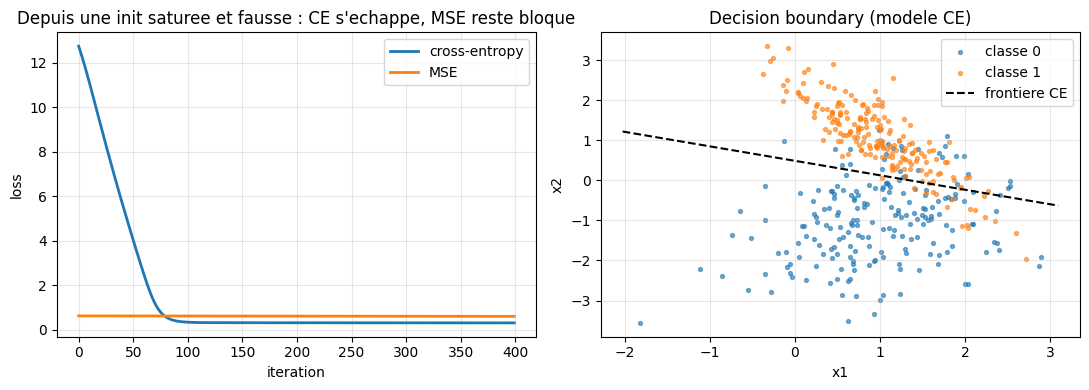

In [4]:
# L'experience decisive : partir SATURE et FAUX, et laisser la perte faire la difference.
import numpy as np, matplotlib.pyplot as plt

w0_sat = np.array([-8.0, -8.0, -8.0])        # init : sigmoide saturee dans le mauvais sens
w_ce, h_ce = entrainer(w0_sat, Xb, y, "ce", 0.2, 400)
w_mse, h_mse = entrainer(w0_sat, Xb, y, "mse", 0.2, 400)
print(f"init saturee et fausse : accuracy {acc(w0_sat, Xb, y):.3f}")
print(f"Cross-entropy : accuracy {acc(w_ce, Xb, y):.3f}  (s'echappe du piege du gradient)")
print(f"MSE          : accuracy {acc(w_mse, Xb, y):.3f}  (reste bloque)")

# Pour un point sature et faux (p≈0, y=1), le gradient passe par p(1-p) : il meurt.
p_sat = 0.02
g_ce = p_sat - 1.0                      # proportionnel a (p - y), y=1
g_mse = (p_sat - 1.0) * p_sat * (1 - p_sat)
print(f"\nPoint sature p={p_sat:.2f}, y=1 : |gradient CE| = {abs(g_ce):.4f}  |  |gradient MSE| = {abs(g_mse):.5f}")
print(f"  rapport CE/MSE = {abs(g_ce) / abs(g_mse):.0f}x  -> le gradient MSE est ~50x plus faible")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(h_ce, label="cross-entropy", lw=2)
axes[0].plot(h_mse, label="MSE", lw=2)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("loss")
axes[0].set_title("Depuis une init saturee et fausse : CE s'echappe, MSE reste bloque")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], s=8, alpha=0.6, label="classe 0")
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], s=8, alpha=0.6, label="classe 1")
xx = np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 200)
yy = -(w_ce[0] * xx + w_ce[2]) / w_ce[1]      # frontiere du modele CE
axes[1].plot(xx, yy, "k--", lw=1.5, label="frontiere CE")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].set_title("Decision boundary (modele CE)")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lecture.** L'expérience décisive part d'une **init saturée et fausse** (accuracy 0,375) : sous **cross-entropy**, le modèle s'échappe et rejoint **~0,88** ; sous **MSE**, il reste coincé vers **0,39**. Le même modèle, la même init — la seule différence est la loss. La courbe le montre : la **cross-entropy** plonge et apprend, la **MSE** reste à plat.

La cause est le facteur $p(1-p)$ que la MSE introduit via la dérivée de la sigmoïde. Au voisinage d'une prédiction saturée **et fausse**, ce facteur est minuscule : le modèle est confiant dans une erreur, et le gradient le punit **à peine** — la mesure (~50× plus faible) le montre. La cross-entropy, elle, garde un gradient proportionnel à $(p - y)$, qui ne s'annule jamais tant que la prédiction est fausse. C'est la raison pour laquelle les classifieurs utilisent la **cross-entropy** et non les moindres carrés, et c'est le premier pont vers les losses du reste de la série.


***

## 4. KL comme distance entre modèles : un mini-modèle de langue et la température

La section 2 a mesuré $D_{KL}(p \| q)$ entre la vérité $p$ et un modèle $q$. Ici on inverse le regard : comparer entre elles deux **distributions de modèle** — c'est exactement ce que fait la régularisation de la série PostTraining, où l'on veut mesurer combien une policy s'éloigne d'une référence.

On construit un **mini-modèle de langue** from scratch : un **bigramme** de caractères entraîné sur le texte français (la probabilité du prochain caractère conditionnée au précédent). C'est un modèle réaliste — non trivial, mais assez petit pour tourner sur CPU. Deux usages :

1. **Qualité prédictive** : un bigramme prédit mieux qu'un unigramme (il capte la structure des suites), donc sa cross-entropy en bits/caractère est plus basse.
2. **Distance par température** : le **sampling par température** applique des logits ré-échelonnés $\mathrm{softmax}(z / T)$ ; une température $T < 1$ **concentre** la distribution, $T > 1$ l'**aplatit**. La KL entre la distribution de référence ($T = 1$) et sa version chauffée/refroidie mesure ce décalage.


In [5]:
# Mini-modele de langue bigramme : P(caractere | caractere precedent), lissage additif.
import numpy as np

def entrainer_bigramme(texte, alphabet):
    idx = {c: i for i, c in enumerate(alphabet)}
    A = len(alphabet)
    compt = np.full((A, A), 1.0)                 # lissage additif : aucun compteur nul
    prec = None
    for c in texte:
        i = idx[c]
        if prec is not None:
            compt[prec, i] += 1
        prec = i
    return compt / compt.sum(axis=1, keepdims=True)   # P[i, j] = P(j | i)

P_bigram = entrainer_bigramme(TEXTE, alphabet)

# Perte en bits/caractere de chaque modele sur le texte : unigramme (empirique) vs bigramme.
idx = {c: i for i, c in enumerate(alphabet)}
uni = p                                    # distribution unigramme (empirique, section 1)
bits_uni = 0.0; bits_bi = 0.0; n_bi = 0; prec = None
for c in TEXTE:
    i = idx[c]
    bits_uni += -np.log2(uni[i] + 1e-12)
    if prec is not None:
        bits_bi += -np.log2(P_bigram[prec, i] + 1e-12)
        n_bi += 1
    prec = i
print(f"perte unigramme : {bits_uni / len(TEXTE):.3f} bits/car.  |  bigramme : {bits_bi / n_bi:.3f} bits/car.")
print(f"gain du bigramme (il predit mieux la structure) : {bits_uni / len(TEXTE) - bits_bi / n_bi:.3f} bits/car.")


perte unigramme : 4.533 bits/car.  |  bigramme : 4.009 bits/car.
gain du bigramme (il predit mieux la structure) : 0.525 bits/car.


caractere contexte = ' '  (le plus frequent) — distribution : [0.003 0.003 0.014 0.003 0.003 0.003]...
  T = 0.3   KL(ref || ref@T) = 1.7047 bits   H(dist) = 3.2406
  T = 1.0   KL(ref || ref@T) = -0.0000 bits   H(dist) = 5.2835
  T = 2.0   KL(ref || ref@T) = 0.1424 bits   H(dist) = 5.7206

minimum de KL sur le balayage en T = 1.00  (attendu : 1.0, temperature neutre)


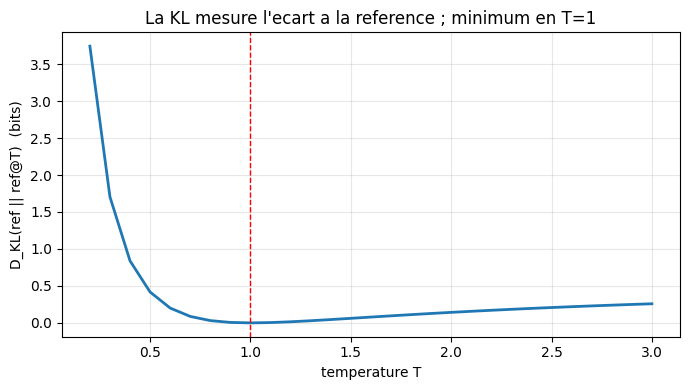

In [6]:
# Distance par temperature : KL(ref || ref@T), minimisee en T=1.
import numpy as np

def softmax_temperature(logits, T):
    logits = np.asarray(logits, dtype=float) / T
    m = logits.max()
    e = np.exp(logits - m)
    return e / e.sum()

def kl(p, q):
    return np.sum(p * np.log2((p + 1e-12) / (q + 1e-12)))

# Contexte le plus frequent (la distribution de reference : ce qui suit ce caractere).
ctx = alphabet[int(np.argmax(p))]
ref = P_bigram[idx[ctx]]                     # distribution de reference (contexte donne)
log_ref = np.log(ref + 1e-12)

print(f"caractere contexte = {ctx!r}  (le plus frequent) — distribution : {np.round(ref[:6], 3)}...")
for T in [0.3, 1.0, 2.0]:
    dist = softmax_temperature(log_ref, T)
    print(f"  T = {T:<4}  KL(ref || ref@T) = {kl(ref, dist):.4f} bits   H(dist) = {entropie_p(dist):.4f}")

# Balayage complet : la KL(ref||ref@T) a bien son minimum en T=1.
Tvals = np.linspace(0.2, 3.0, 29)
Kvals = [kl(ref, softmax_temperature(log_ref, T)) for T in Tvals]
Tmin = Tvals[int(np.argmin(Kvals))]
print(f"\nminimum de KL sur le balayage en T = {Tmin:.2f}  (attendu : 1.0, temperature neutre)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Tvals, Kvals, lw=2)
ax.axvline(1.0, color="red", ls="--", lw=1)
ax.set_xlabel("temperature T")
ax.set_ylabel("D_KL(ref || ref@T)  (bits)")
ax.set_title("La KL mesure l'ecart a la reference ; minimum en T=1")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lecture.** Le mini-modèle **bigramme** prédit nettement mieux que l'unigramme : sa perte en bits par caractère est plus basse, et le gain mesure la structure que la langue impose aux *suites* de caractères. C'est une première lecture de la KL : entre deux modèles, celui qui prédit mieux a la **cross-entropy la plus basse**, donc la **KL la plus petite** vis-à-vis de la vérité.

La **température** montre le second visage de la KL : la distribution de référence ($T = 1$) et sa version chauffée ou refroidie diffèrent, et la KL entre elles est **minimale en $T = 1$** (où $D_{KL}(q \| q) = 0$) et croît de part et d'autre. Cold sampling ($T < 1$) aplatit la distribution et la détache de la référence ; hot sampling ($T > 1$) la concentre. La KL est donc une **mesure de décalage** entre deux distributions de sortie — exactement la grandeur que la régularisation KL de PostTraining va contraindre, comme on le voit dans la section 5.


***

## 5. Les ponts : les mêmes quantités dans DPO et GRPO

Les deux grandeurs manipulées ici — la **cross-entropy** et la **divergence de KL** — sont les briques des losses de toute la série. Deux exemples précis, dans [PT_03](../../../GenAI/PostTraining/PT_03_dpo_direct_preference.ipynb) (DPO) et [PT_04](../../../GenAI/PostTraining/PT_04_grpo_deepseek_r1.ipynb) :

- **DPO (PT_03)** : la récompense implicite est $\beta \cdot \log \frac{\pi_\theta}{\pi_{ref}}$, et la loss est un `-log sigmoid` du **différentiel de log-rapports** entre la réponse choisie et la réponse rejetée. C'est un **log-ratio de probabilités** ($\log \pi_\theta - \log \pi_{ref}$) — la même différence de log-probas que notre $\log_2 \frac{p}{q}$, à la base près. Le paramètre $\beta = 0.1$ (PT_03) est le **coefficient de régularisation KL**.
- **GRPO/PPO (PT_04)** : la loss est un `clipped surrogate` $\min(r_i \hat{A}_i, \mathrm{clip}(r_i, 1-\varepsilon, 1+\varepsilon) \hat{A}_i)$ **plus un penalty KL** $\beta \cdot D_{KL}(\pi_\theta \| \pi_{ref})$. Le `ratio` $r_i = \pi_\theta / \pi_{old}$ est un rapport de probabilités, et le penalty KL est **exactement** notre $D_{KL}$ de la section 2. Le $\beta = 0.04$ (PT_04, défaut DeepSeek) règle la force de ce rappel vers la référence.

Le **piège du $\log 0$** de la section 2 se manifeste ici, en pratique, sous le nom de **KL collapse** : si $\beta$ est trop faible, la policy diverge de la référence ($\pi_\theta / \pi_{ref}$ explose), le log-ratio sature, la loss se corrompt. Comprendre la positivité de la KL et le coût d'un zéro de probabilité, c'est comprendre pourquoi on borne $\beta$ et pourquoi on lisse. On le calcule numériquement ci-dessous : tout se réduit aux deux primitives de la section 2.


In [7]:
# Les memes primitives dans le loss DPO et le penalty KL de GRPO.
import numpy as np

def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def kl(p, q):
    return np.sum(p * np.log2((p + 1e-12) / (q + 1e-12)))

# Deux logits (policy vs reference) sur 4 "tokens" d'un vocabulaire-jouet.
logits_policy = np.array([3.0, 1.5, 4.0, 0.5])
logits_ref    = np.array([2.8, 2.6, 3.2, 1.8])
pi = softmax(logits_policy)
pi_ref = softmax(logits_ref)

log_ratio = np.log(pi) - np.log(pi_ref)          # log(pi_theta) - log(pi_ref)
print("log-ratio (pi_theta / pi_ref) :", np.round(log_ratio, 3))
print("recompense implicite DPO  (beta=0.1 * log-ratio) :", np.round(0.1 * log_ratio, 3))

# Loss DPO = -log sigmoid(beta * (log-ratio_choisi - log-ratio_rejete))
lr_c = log_ratio[2]    # "choisi"  (le token ou la policy est la plus confiante)
lr_r = log_ratio[1]    # "rejete"
loss_dpo = -np.log(sigmoid(0.1 * (lr_c - lr_r)))
print(f"loss DPO = -log sigmoid(beta*(log-ratio_choisi - log-ratio_rejete)) = {loss_dpo:.4f}")

# Penalty KL de GRPO : D_KL(pi_theta || pi_ref) = sum pi_theta * log-ratio  (exactement la section 2)
kl_grpo = kl(pi, pi_ref)
print(f"KL(pi_theta || pi_ref) = {kl_grpo:.4f} bits  = sum pi_theta * log-ratio  ->  le terme penalite de PT_04")


log-ratio (pi_theta / pi_ref) : [-0.09 -1.39  0.51 -1.59]
recompense implicite DPO  (beta=0.1 * log-ratio) : [-0.009 -0.139  0.051 -0.159]
loss DPO = -log sigmoid(beta*(log-ratio_choisi - log-ratio_rejete)) = 0.6027
KL(pi_theta || pi_ref) = 0.3073 bits  = sum pi_theta * log-ratio  ->  le terme penalite de PT_04


**Lecture.** Le calcul se réduit à une seule ligne : $\log \pi_\theta - \log \pi_{ref}$ est la même différence de log-probas que $\log \frac{p}{q}$, et le penalty KL de GRPO est *littéralement* notre $D_{KL}$ de la section 2 (une somme pondérée de log-ratios par $\pi_\theta$). Tout le loss DPO est un `-log sigmoid` d'un **différentiel de log-ratios** — la cross-entropy « modifiée » que PT_03 évoquait. Les deux séries consomment donc exactement les deux quantités qu'on a construites et vérifiées ici : la **cross-entropy** pour l'ajustement, la **KL** pour le rappel vers une référence.

Et le **KL collapse** que les deux notebooks signalent (les « Pièges » de PT_03 et PT_04) n'est autre que le $\log 0$ de la section 2 et la positivité de la KL : un $\beta$ trop faible laisse le log-ratio diverger, la probabilité tend vers $0$, et la loss explose. Tout est cohérent depuis la section 2.


**Exercices**

Les exercices ci-dessous sont des **stubs** à compléter. Ils conservent les conventions du notebook (cellules exécutables de bout en bout, `# TODO étudiant` marque le travail à faire).


In [8]:
# Exercice 1 : entropie d'un second texte (anglais) et redondance
# TODO etudiant : implementer entropie_texte(texte) en reutilisant compter_caracteres + entropie,
#   puis comparer la redondance du francais (TEXTE) et de l'anglais (TEXTE_2).

TEXTE_2 = """The quick brown fox jumps over the lazy dog. Pack my box with five dozen liquor jugs."""

def entropie_texte(texte):
    """TODO etudiant : retourner l'entropie (bits/caractere) du texte.
    Indice : occ = compter_caracteres(texte) ; return entropie(occ)."""
    pass
    return None

print("Exercice a completer : entropie(TEXTE) vs entropie(TEXTE_2), et redondance de chaque (H / log2(K)).")


Exercice a completer : entropie(TEXTE) vs entropie(TEXTE_2), et redondance de chaque (H / log2(K)).


In [9]:
# Exercice 2 : lissage additif et le piege du log(0)
# TODO etudiant : implementer ce_smoothed(p, q, alpha) qui ajoute alpha a chaque composante de q
#   avant normalisation, et montrer que la cross-entropy devient finie meme ou le modele mettait 0.

def ce_smoothed(p, q, alpha):
    """TODO etudiant : retourner -sum p log2(normaliser(q + alpha)).
    Indice : q_s = (q + alpha) ; q_s = q_s / q_s.sum() ; return -sum(p * log2(q_s + 1e-12))."""
    pass
    return None

print("Exercice a completer : faire converger la cross-entropy sur q_zero en augmentant alpha.")


Exercice a completer : faire converger la cross-entropy sur q_zero en augmentant alpha.


In [10]:
# Exercice 3 : la KL en fonction de la temperature — verifier le minimum en T=1
# TODO etudiant : balayer T de 0.2 a 3.0, calculer KL(ref || softmax_temperature(log(ref+eps), T)),
#   tracer KL(T) et confirmer que le minimum est en T=1 (temperature neutre).

def kl_T(ref, T):
    """TODO etudiant : KL(ref || ref@T) pour une temperature T, en reutilisant kl(...) de la section 4."""
    pass
    return None

print("Exercice a completer : minimiser KL(T) par balayage — attendu en T = 1.")


Exercice a completer : minimiser KL(T) par balayage — attendu en T = 1.


## Conclusion et transition

Trois quantités, un seul fil. L'**entropie** $H(p)$ mesure la surprise moyenne d'une source — la compressibilité intrinsèque. La **cross-entropy** $H(p, q)$ mesure le coût de croire un modèle $q$ alors que la vérité est $p$. La **divergence de KL** $D_{KL}(p \| q) = H(p, q) - H(p)$ isole le surcoût de $q$ : positive, nulle ssi $p = q$ (Gibbs), asymétrique. La section 3 a montré pourquoi la cross-entropy, et non la MSE, est la bonne loss d'un classifieur ; la section 4 a montré la KL comme mesure de décalage entre modèles (la température) ; la section 5 a relié le tout aux losses que la série PostTraining consomme réellement (DPO, GRPO) — les mêmes primitives, le même piège du $\log 0$.

C'est la fondation de la série 03 : dès le 3.1, la **rétropropagation** dérivera ce qu'on optimise exactement ici ; le 3.2 (Adam) mettra à jour les poids qui minimisent cette cross-entropy ; le 3.3 verra comment la régularisation pénalise la complexité indépendamment de la loss. Et les séries appliquées (RL, PostTraining, ML-Training-Pipeline) retrouveront ces deux quantités sous les noms de `loss` et de `kl`.

## Références

1. Shannon, C. E. (1948). *A Mathematical Theory of Communication*. Bell System Technical Journal, 27, 379–423.
2. Kullback, S. & Leibler, R. A. (1951). *On Information and Sufficiency*. Annals of Mathematical Statistics, 22(1), 79–86.
3. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*, « Information Theory » (ch. 5). MIT Press.
